# Visualizing 4D Iris data in 2D with SOM
We explore SOM as a topology-preserving neural approach to structured visualization

In [1]:
# Load and Preprocess the Dataset
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

## Dataset

We use the Iris dataset:
- 4 features (high-dimensional input)
- 3 classes (for visualization only)

We normalize the data to improve training stability.

In [2]:
# Load dataset
iris = load_iris()
data = iris.data
labels = iris.target

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Convert to PyTorch
X = torch.tensor(data, dtype=torch.float32)

## SOM Implementation

We implement SOM as a PyTorch module:
- Fully vectorized
- Easy to extend

In [3]:
# SOM Model
class SOM(nn.Module):
    def __init__(self, m, n, dim):
        super().__init__()
        self.m = m
        self.n = n
        self.dim = dim

        # Weight vectors
        self.weights = nn.Parameter(torch.rand(m * n, dim))

        # Grid locations
        coords = [(i, j) for i in range(m) for j in range(n)]
        self.locations = torch.tensor(coords, dtype=torch.float32)

    def forward(self, x):
        # Compute distances to all neurons
        dists = torch.cdist(x.unsqueeze(0), self.weights.unsqueeze(0))
        return dists.squeeze()

    def find_bmu(self, x):
        dists = self.forward(x)
        return torch.argmin(dists)

    def update(self, x, bmu_idx, lr, sigma):
        bmu_loc = self.locations[bmu_idx]

        # Distance on grid
        grid_dists = torch.norm(self.locations - bmu_loc, dim=1)

        # Gaussian neighborhood
        h = torch.exp(-grid_dists**2 / (2 * sigma**2))

        # Update weights
        delta = lr * h.unsqueeze(1) * (x - self.weights)
        self.weights.data += delta

## Training

We gradually decrease:
- Learning rate
- Neighborhood radius

This allows:
- Early global organization
- Late fine-tuning

In [4]:
# Training Loop
som = SOM(10, 10, dim=4)

num_epochs = 100
initial_lr = 0.5
initial_sigma = 3.0

for epoch in range(num_epochs):
    lr = initial_lr * (1 - epoch / num_epochs)
    sigma = initial_sigma * (1 - epoch / num_epochs)

    for x in X:
        bmu_idx = som.find_bmu(x)
        som.update(x, bmu_idx, lr, sigma)

print("Training complete.")

Training complete.


## U-Matrix (Unified Distance Matrix)

The U-Matrix shows:
- Distance between neighboring neurons
- Cluster boundaries

High values → separation between clusters<br>
Low values → similar regions

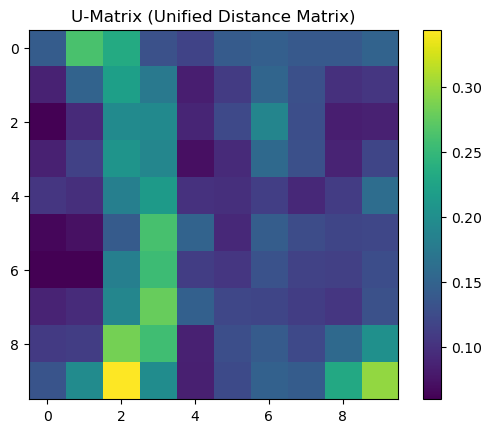

In [5]:
# Visualize the U-Matrix
def compute_u_matrix(som):
    weights = som.weights.detach()
    locations = som.locations

    u_matrix = torch.zeros(len(weights))

    for i in range(len(weights)):
        neighbors = []
        for j in range(len(weights)):
            if torch.norm(locations[i] - locations[j]) == 1:
                neighbors.append(torch.norm(weights[i] - weights[j]))

        if neighbors:
            u_matrix[i] = torch.mean(torch.tensor(neighbors))

    return u_matrix.reshape(som.m, som.n)

u_matrix = compute_u_matrix(som)

plt.figure()
plt.imshow(u_matrix.T)
plt.colorbar()
plt.title("U-Matrix (Unified Distance Matrix)")
plt.show()

## Mapping Data to the Grid

Each data point is assigned to its BMU.

This creates:
- Clusters on the grid
- Structured visualization

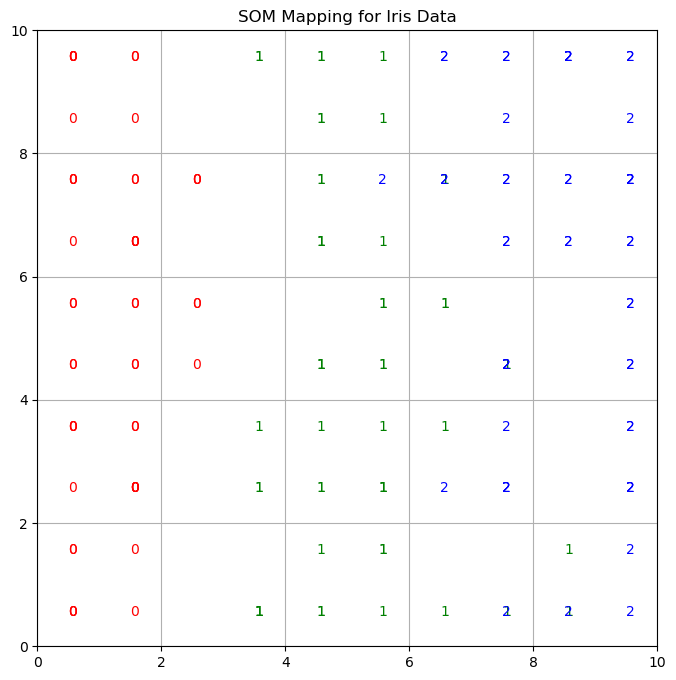

In [6]:
# Mapping Data to Grid
plt.figure(figsize=(8, 8))

for i, x in enumerate(X):
    bmu = som.find_bmu(x)
    coord = som.locations[bmu]

    plt.text(coord[0].item() + 0.5,
             coord[1].item() + 0.5,
             str(labels[i]),
             color=['r','g','b'][labels[i]])

plt.xlim(0, som.m)
plt.ylim(0, som.n)
plt.grid()
plt.title("SOM Mapping for Iris Data")
plt.show()

## SOM in Modern Machine Learning

In practice, SOM is rarely applied to raw features.

Instead:
> Data → Neural Network → Embeddings → SOM

We demonstrate this using a simple autoencoder.

In [7]:
# Simple autoencoder 
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


ae = Autoencoder(4, latent_dim=2)
optimizer = torch.optim.Adam(ae.parameters(), lr=0.01)

# Train briefly
for epoch in range(200):
    optimizer.zero_grad()
    recon, z = ae(X)
    loss = ((recon - X)**2).mean()
    loss.backward()
    optimizer.step()

# Use embeddings
_, Z = ae(X)

print("Latent representation shape:", Z.shape)

Latent representation shape: torch.Size([150, 2])


## SOM on Learned Representations

Now we apply SOM to the latent space.

In [8]:
som_latent = SOM(10, 10, dim=2)

for epoch in range(100):
    lr = 0.5 * (1 - epoch / 100)
    sigma = 3.0 * (1 - epoch / 100)

    for z in Z:
        bmu_idx = som_latent.find_bmu(z)
        som_latent.update(z, bmu_idx, lr, sigma)